In [1]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# Define paths
zip_path = "/content/drive/My Drive/archive (8).zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Streaming output truncated to the last 5000 lines.
/content/unzipped_folder/Negative/13479.jpg
/content/unzipped_folder/Negative/16091.jpg
/content/unzipped_folder/Negative/02250.jpg
/content/unzipped_folder/Negative/00883.jpg
/content/unzipped_folder/Negative/08340.jpg
/content/unzipped_folder/Negative/03126.jpg
/content/unzipped_folder/Negative/08971.jpg
/content/unzipped_folder/Negative/16978.jpg
/content/unzipped_folder/Negative/06896.jpg
/content/unzipped_folder/Negative/18159.jpg
/content/unzipped_folder/Negative/19459.jpg
/content/unzipped_folder/Negative/14282.jpg
/content/unzipped_folder/Negative/04860.jpg
/content/unzipped_folder/Negative/00130.jpg
/content/unzipped_folder/Negative/15108.jpg
/content/unzipped_folder/Negative/18839.jpg
/content/unzipped_folder/Negative/00241.jpg
/content/unzipped_folder/Negative/18465.jpg
/content/unzipped_folder/Negative/08221.jpg
/content/unzipped_folder/Negative/19023.jpg
/content/unzipped_folder/Negative/14923.jpg
/content/unzipped_folder/

Found 32000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.


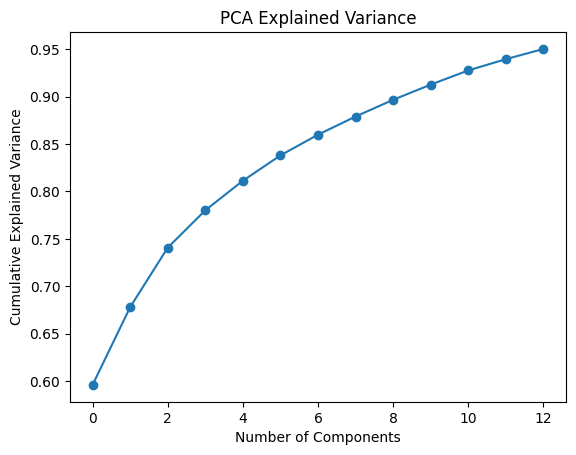

Feature Importances Computed.


In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

# Define paths
base_dir = '/content/unzipped_folder'  # Update if necessary
positive_dir = os.path.join(base_dir, 'positive')  # Cracks present
negative_dir = os.path.join(base_dir, 'negative')  # No cracks

# Image parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20,
                                   width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                                   zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Extract features and labels
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Flatten images for PCA analysis
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_val_flattened = X_val.reshape(X_val.shape[0], -1)

# PCA Analysis
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_flattened)
X_val_pca = pca.transform(X_val_flattened)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

# Decision Tree Feature Importance (Using Flattened Data)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_flattened, y_train)
feature_importances = tree.feature_importances_
print("Feature Importances Computed.")

# Normalize Data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_flattened)
X_val_scaled = scaler.transform(X_val_flattened)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)






In [4]:
# Define KNN classifier
k = 5  # Number of neighbors, tune this for better performance
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train_encoded)

# Predict on validation data
y_pred_knn = knn.predict(X_val_scaled)

# Evaluate KNN model
accuracy_knn = accuracy_score(y_val_encoded, y_pred_knn) * 100
print(f"KNN Accuracy: {accuracy_knn:.2f}%")


KNN Accuracy: 62.50%


True Positives (TP): 3
True Negatives (TN): 17
False Positives (FP): 0
False Negatives (FN): 12


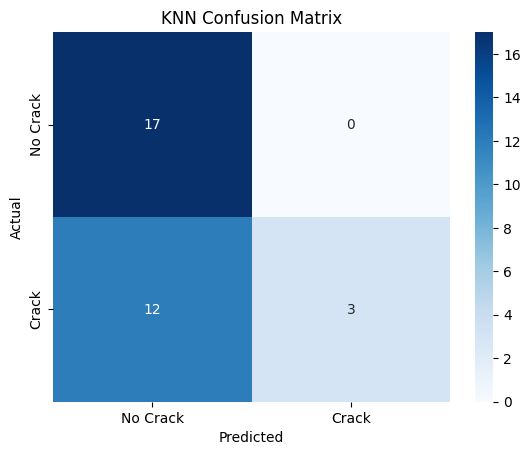

In [5]:
# Compute Confusion Matrix
conf_matrix_knn = confusion_matrix(y_val_encoded, y_pred_knn)
tn, fp, fn, tp = conf_matrix_knn.ravel()  # Extract TP, TN, FP, FN

print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Plot Confusion Matrix for KNN
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crack', 'Crack'], yticklabels=['No Crack', 'Crack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()
